LSTM Neural Network Model Experiments for Multi-Class Classification
---
Performs grid search on 144 different configurations to determine the best (Bi)LSTM NN model for dementia classifcation across 3 classes: Healthy Control (0), Mild Cognitive Impairment (1), and Dementia (2).

Grid search is run on all three transcript types to determine the best model for each PFT, CTD, and SFT.

**Instructions**: Run the cells in order to load the data, understand its shape, distributions, vocab sizes, etc., tokenize and pad text, and execute grid search. After grid search is executed, the best configuration is determined from the highest mean macro F1 scores for each transcript and that model is rerun to generate the confusion matrices and reports. 

In [10]:
import sys
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer

sys.path.append(str(Path("..").resolve()))

DATA_PATH = Path("..") / "data" / "transcripts_cleaned.csv"

transcript_df = pd.read_csv(DATA_PATH)

print(transcript_df.shape)
transcript_df.head()

(157, 7)


,Record-ID,Class,Transcript_PFT,Transcript_CTD,Transcript_SFT,Label,Binary_Label
0,Process-rec-001,MCI,"people, partner, plate, platter, pants, porter...",NaN,"<pause_medium> giraffe, kangaroo, lion, tiger,...",1,1
1,Process-rec-002,MCI,"<pause_short> pipe, plane, people <pause_mediu...",<pause_medium> there’s a lad stood on the stoo...,"<pause_short> dogs, cats, birds <pause_short> ...",1,1
2,Process-rec-003,MCI,"um <pause_short> purple, pale, placid <pause_s...","<pause_medium> um, the picture is of a kitchen...","cow, bull, ewe, ram, chicken, goose, um <sigh>...",1,1
3,Process-rec-004,MCI,plank <pause_short> pool <pause_short> swimmin...,"a mother presumably, or a fe, an adult female ...",um <pause_short> impala <pause_short> er cheet...,1,1
4,Process-rec-005,MCI,"it’s er pillock, er post box, er pyracanthas, ...","‘50s style er scene of domestic um confusion, ...","dog, cat, giraffe, wallaby, kangaroo, tortoise...",1,1


In [11]:
TRANSCRIPT_COLS = ["Transcript_PFT", "Transcript_CTD", "Transcript_SFT"]

print("NaN counts per transcript type: ")
for col in TRANSCRIPT_COLS:
    n_nans = transcript_df[col].isna().sum()
    print(f"{col}: {n_nans} NaNs")

NaN counts per transcript type: 
Transcript_PFT: 0 NaNs
Transcript_CTD: 1 NaNs
Transcript_SFT: 5 NaNs


In [12]:
from transcript_preprocessing import load_transcript_splits
df_by_transcript = load_transcript_splits(DATA_PATH)

for col in TRANSCRIPT_COLS:
    print(f"After removing NaNs for {col}: {len(df_by_transcript[col])} samples")

for col, df_clean in df_by_transcript.items():
    print(f"\nLabel counts for {col}:")
    print(df_clean["Class"].value_counts())


After removing NaNs for Transcript_PFT: 157 samples
After removing NaNs for Transcript_CTD: 156 samples
After removing NaNs for Transcript_SFT: 152 samples

Label counts for Transcript_PFT:
Class
HC          82
MCI         59
Dementia    16
Name: count, dtype: int64

Label counts for Transcript_CTD:
Class
HC          82
MCI         58
Dementia    16
Name: count, dtype: int64

Label counts for Transcript_SFT:
Class
HC          78
MCI         58
Dementia    16
Name: count, dtype: int64


In [4]:
# Analyze transcript lengths and vocab sizes to determine how to set max lengths anf if voacb limiting is necessary
length_stats = {}

for col in TRANSCRIPT_COLS:
    print(f"\n{col}:")
    
    df = df_by_transcript[col]
    texts = df[col].astype(str).tolist()
    
    # Fit tokenizer for analysis
    tokenizer = Tokenizer(oov_token="<UNK>")
    tokenizer.fit_on_texts(texts)
    
    vocab_size = len(tokenizer.word_index)
    
    # Convert to sequences
    sequences = tokenizer.texts_to_sequences(texts)
    lengths = np.array([len(seq) for seq in sequences])
    
    length_stats[col] = {
        "lengths": lengths,
        "tokenizer": tokenizer,
        "vocab_size": vocab_size,
    }
    
    print(f"Number of samples: {len(lengths)}")
    print(f"Vocab size (unique tokens): {vocab_size}")
    print(f"Min length:       {lengths.min()}")
    print(f"Max length:       {lengths.max()}")
    print(f"Mean length:      {lengths.mean():.2f}")



Transcript_PFT:
Number of samples: 157
Vocab size (unique tokens): 1267
Min length:       13
Max length:       94
Mean length:      47.58

Transcript_CTD:
Number of samples: 156
Vocab size (unique tokens): 1400
Min length:       13
Max length:       474
Mean length:      163.89

Transcript_SFT:
Number of samples: 152
Vocab size (unique tokens): 931
Min length:       25
Max length:       121
Mean length:      62.91


In [13]:
MAX_LEN_PFT = 94
MAX_LEN_CTD = 474
MAX_LEN_SFT = 121

MAX_LEN_BY_TRANSCRIPT = {
    "Transcript_PFT": MAX_LEN_PFT,
    "Transcript_CTD": MAX_LEN_CTD,
    "Transcript_SFT": MAX_LEN_SFT,
}

In [6]:
from transcript_preprocessing import get_stratified_kfold_splits
from utils import prepare_fold_data

# Verify padding/tokenization for each transcript type (for first fold only)
for transcript_col in TRANSCRIPT_COLS:
    print(f"\n{transcript_col}:")
    
    df = df_by_transcript[transcript_col]
    max_len = MAX_LEN_BY_TRANSCRIPT[transcript_col]
    
    y = df["Label"].values
    
    # Run Stratified K-Fold, and inspect the first fold
    for fold_idx, train_idx, val_idx in get_stratified_kfold_splits(
        transcript_df=df,
        transcript_col=transcript_col,
        label_col="Label",
        n_splits=5,
        seed=42,
    ):
        print(f"Fold {fold_idx}")
        
        X_train, y_train, X_val, y_val, tokenizer, vocab_size = prepare_fold_data(
            df=df,
            transcript_col=transcript_col,
            label_col="Label",
            train_idx=train_idx,
            val_idx=val_idx,
            max_len=max_len,
        )
        
        print("  X_train shape:", X_train.shape)
        print("  X_val shape:  ", X_val.shape)
        print("  y_train shape:", y_train.shape)
        print("  y_val shape:  ", y_val.shape)
        print("  max_len used: ", max_len)
        print("  vocab_size:   ", vocab_size)
        break



Transcript_PFT:
Fold 1
  X_train shape: (125, 94)
  X_val shape:   (32, 94)
  y_train shape: (125,)
  y_val shape:   (32,)
  max_len used:  94
  vocab_size:    1125

Transcript_CTD:
Fold 1
  X_train shape: (124, 474)
  X_val shape:   (32, 474)
  y_train shape: (124,)
  y_val shape:   (32,)
  max_len used:  474
  vocab_size:    1298

Transcript_SFT:
Fold 1
  X_train shape: (121, 121)
  X_val shape:   (31, 121)
  y_train shape: (121,)
  y_val shape:   (31,)
  max_len used:  121
  vocab_size:    873


In [9]:
from utils import make_config_grid

# Hyperparameter options for grid search
MODEL_TYPES = ["lstm", "bilstm"]
EMBEDDING_DIMS = [100, 200]
LSTM_UNITS = [16, 64, 128]
DROPOUT_RATES = [0.3]
RECURRENT_DROPOUT_RATES = [0.0, 0.1, 0.2]
DENSE_UNITS_OPTIONS = [0, 64]  # 0 = no dense layer, 64 = add dense hidden layer
LEARNING_RATES = [1e-3, 5e-4]

config_grid = make_config_grid(
    MODEL_TYPES,
    EMBEDDING_DIMS,
    LSTM_UNITS,
    DROPOUT_RATES,
    RECURRENT_DROPOUT_RATES,
    DENSE_UNITS_OPTIONS,
    LEARNING_RATES,
)

print(f"Total configs: {len(config_grid)}")

Total configs: 144


In [ ]:
from utils import run_cv_for_config
# Suppress TensorFlow warnings
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

all_results = []

# main grid search loop
# NOTE: This took ~10 hours to run
for transcript_col in TRANSCRIPT_COLS:
    df = df_by_transcript[transcript_col]
    max_len = MAX_LEN_BY_TRANSCRIPT[transcript_col]

    print(f"\nGrid search for {transcript_col}:")
    print(f"Num samples: {len(df)}, max_len: {max_len}")

    for i, config in enumerate(config_grid, start=1):
        print(f"\n[{transcript_col}] Config {i}: {config}")

        summary = run_cv_for_config(
            transcript_col=transcript_col,
            df=df,
            config=config,
            max_len=max_len,
            n_splits=5,
            seed=42,
            batch_size=16,
            max_epochs=30,
        )

        # Merge config + metrics into one flat dict
        result_row = {
            "transcript_col": transcript_col,
            **config,
            **summary,
        }
        all_results.append(result_row)

# Convert to DataFrame and save results
results_df = pd.DataFrame(all_results)
results_df.to_csv("lstm_bilstm_grid_search_results.csv", index=False)

# See top configs per transcript type sorted by mean_macro_f1
display(
    results_df.sort_values(
        ["transcript_col", "mean_macro_f1"],
        ascending=[True, False],
    ).groupby("transcript_col").head(5)
)


Grid search for Transcript_PFT:
Num samples: 157, max_len: 94

[Transcript_PFT] Config 1: {'model_type': 'lstm', 'embedding_dim': 100, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.0, 'dense_units': 0, 'learning_rate': 0.001}

[Transcript_PFT] Config 2: {'model_type': 'lstm', 'embedding_dim': 100, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.0, 'dense_units': 0, 'learning_rate': 0.0005}

[Transcript_PFT] Config 3: {'model_type': 'lstm', 'embedding_dim': 100, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.0, 'dense_units': 64, 'learning_rate': 0.001}

[Transcript_PFT] Config 4: {'model_type': 'lstm', 'embedding_dim': 100, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.0, 'dense_units': 64, 'learning_rate': 0.0005}

[Transcript_PFT] Config 5: {'model_type': 'lstm', 'embedding_dim': 100, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.1, 'dense_units': 0, 'learning_rate': 0.001}

[Transcript_PFT] Config 6: {'model_type': 'lstm', 'embedd

,transcript_col,model_type,embedding_dim,lstm_units,dropout,recurrent_dropout,dense_units,learning_rate,mean_accuracy,std_accuracy,...,mean_weighted_f1,std_weighted_f1,mean_precision_macro,std_precision_macro,mean_recall_macro,std_recall_macro,mean_precision_weighted,std_precision_weighted,mean_recall_weighted,std_recall_weighted
257,Transcript_CTD,bilstm,200,16,0.3,0.1,0,0.0005,0.570363,0.086144,...,0.544669,0.099979,0.473994,0.125018,0.458259,0.112886,0.558690,0.096792,0.570363,0.086144
225,Transcript_CTD,bilstm,100,16,0.3,0.2,0,0.0005,0.608871,0.072221,...,0.574542,0.080471,0.452186,0.087805,0.451248,0.079902,0.582982,0.081203,0.608871,0.072221
220,Transcript_CTD,bilstm,100,16,0.3,0.1,0,0.0010,0.582863,0.107444,...,0.553767,0.110334,0.453215,0.126933,0.447512,0.093520,0.570746,0.111353,0.582863,0.107444
152,Transcript_CTD,lstm,100,16,0.3,0.2,0,0.0010,0.532056,0.082873,...,0.532884,0.076373,0.444737,0.072910,0.433608,0.076552,0.564647,0.057280,0.532056,0.082873
187,Transcript_CTD,lstm,200,16,0.3,0.1,64,0.0005,0.511895,0.107746,...,0.466728,0.067752,0.505905,0.111337,0.483994,0.076870,0.543282,0.103684,0.511895,0.107746
49,Transcript_PFT,lstm,200,64,0.3,0.0,0,0.0005,0.490323,0.089280,...,0.466952,0.100532,0.388200,0.098357,0.407130,0.104249,0.460411,0.109152,0.490323,0.089280
68,Transcript_PFT,lstm,200,128,0.3,0.2,0,0.0010,0.508871,0.085069,...,0.447991,0.100878,0.346505,0.089652,0.443219,0.074637,0.417780,0.108999,0.508871,0.085069
75,Transcript_PFT,bilstm,100,16,0.3,0.0,64,0.0005,0.490524,0.058633,...,0.445945,0.044976,0.440728,0.127419,0.397497,0.087218,0.518850,0.094177,0.490524,0.058633
108,Transcript_PFT,bilstm,200,16,0.3,0.0,0,0.0010,0.433468,0.070498,...,0.413822,0.060648,0.377434,0.146324,0.386713,0.094584,0.426201,0.078730,0.433468,0.070498
32,Transcript_PFT,lstm,100,128,0.3,0.2,0,0.0010,0.470766,0.056946,...,0.438678,0.057034,0.394464,0.129827,0.376478,0.070352,0.448211,0.080620,0.470766,0.056946


In [24]:
best_configs = {}

for col in TRANSCRIPT_COLS:
    subset = results_df[results_df["transcript_col"] == col]
    # pick row with highest mean_macro_f1
    best_row = subset.sort_values("mean_macro_f1", ascending=False).iloc[0]
    cfg = {
        "model_type": str(best_row["model_type"]),
        "embedding_dim": int(best_row["embedding_dim"]),
        "lstm_units": int(best_row["lstm_units"]),
        "dropout": float(best_row["dropout"]),
        "recurrent_dropout": float(best_row["recurrent_dropout"]),
        "dense_units": int(best_row["dense_units"]),
        "learning_rate": float(best_row["learning_rate"]),
    }
    best_configs[col] = cfg
    print(f"\nBest config for {col}:")
    print(cfg)
    print("mean_macro_f1:", best_row["mean_macro_f1"])


Best config for Transcript_PFT:
{'model_type': 'lstm', 'embedding_dim': 200, 'lstm_units': 64, 'dropout': 0.3, 'recurrent_dropout': 0.0, 'dense_units': 0, 'learning_rate': 0.0005}
mean_macro_f1: 0.3872890979987754

Best config for Transcript_CTD:
{'model_type': 'bilstm', 'embedding_dim': 200, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.1, 'dense_units': 0, 'learning_rate': 0.0005}
mean_macro_f1: 0.4492051854574467

Best config for Transcript_SFT:
{'model_type': 'bilstm', 'embedding_dim': 200, 'lstm_units': 128, 'dropout': 0.3, 'recurrent_dropout': 0.1, 'dense_units': 0, 'learning_rate': 0.0005}
mean_macro_f1: 0.48026204938282246


In [14]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)

from keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

from transcript_preprocessing import get_stratified_kfold_splits
from utils import prepare_fold_data, build_lstm_model

def run_cv_collect_predictions(
    transcript_col,
    df,
    config,
    max_len,
    n_splits=5,
    seed=42,
    batch_size=16,
    max_epochs=30,
):
    """
    Re-run stratified K-fold CV for a given transcript type and config,
    collect predictions across all folds, and compute per-fold metrics.
    Returns:
        y_true_all, y_pred_all, fold_metrics
    """
    all_true = []
    all_pred = []
    fold_metrics = []

    for fold_idx, train_idx, val_idx in get_stratified_kfold_splits(
        transcript_df=df,
        transcript_col=transcript_col,
        label_col="Label",
        n_splits=n_splits,
        seed=seed,
    ):
        # Prepare data for this fold
        X_train, y_train, X_val, y_val, tokenizer, vocab_size = prepare_fold_data(
            df=df,
            transcript_col=transcript_col,
            label_col="Label",
            train_idx=train_idx,
            val_idx=val_idx,
            max_len=max_len,
        )

        model = build_lstm_model(
            config=config,
            vocab_size=vocab_size,
            max_len=max_len,
            num_classes=3,
        )

        # Class weights for imbalance
        classes = np.unique(y_train)
        class_weights_array = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=y_train,
        )
        class_weight = {int(c): float(w) for c, w in zip(classes, class_weights_array)}

        callbacks = [
            EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True,
                verbose=0,
            )
        ]

        # Train
        model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=max_epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=0,
            class_weight=class_weight,
        )

        # Predict on this fold's validation set
        y_prob = model.predict(X_val, batch_size=batch_size, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        all_true.append(y_val)
        all_pred.append(y_pred)

        # Per-fold metrics
        acc = accuracy_score(y_val, y_pred)
        macro_f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(y_val, y_pred, average="weighted", zero_division=0)
        precision_macro, recall_macro, _, _ = precision_recall_fscore_support(
            y_val, y_pred, average="macro", zero_division=0
        )

        fold_metrics.append(
            {
                "fold": fold_idx,
                "accuracy": acc,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1,
                "precision_macro": precision_macro,
                "recall_macro": recall_macro,
            }
        )

    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)

    return y_true_all, y_pred_all, fold_metrics


Confusion matrix for Transcript_PFT:


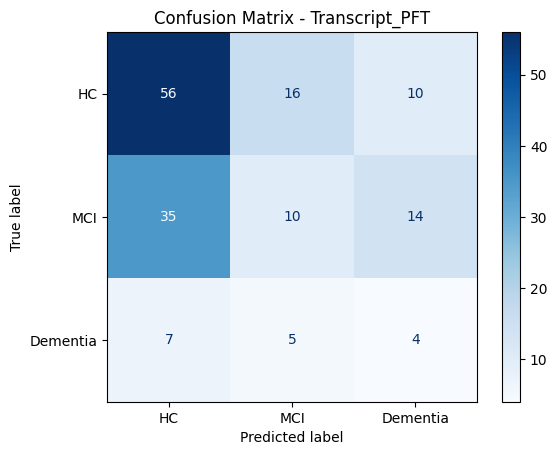

Classification report:
              precision    recall  f1-score   support

          HC       0.57      0.68      0.62        82
         MCI       0.32      0.17      0.22        59
    Dementia       0.14      0.25      0.18        16

    accuracy                           0.45       157
   macro avg       0.35      0.37      0.34       157
weighted avg       0.43      0.45      0.43       157

Mean accuracy over folds: 0.445
Mean macro F1 over folds: 0.314

Confusion matrix for Transcript_CTD:


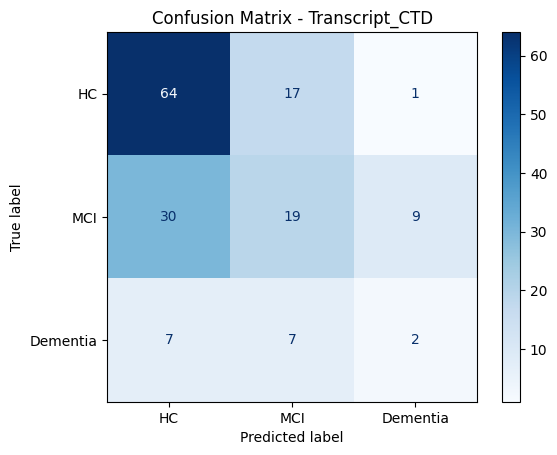

Classification report:
              precision    recall  f1-score   support

          HC       0.63      0.78      0.70        82
         MCI       0.44      0.33      0.38        58
    Dementia       0.17      0.12      0.14        16

    accuracy                           0.54       156
   macro avg       0.41      0.41      0.41       156
weighted avg       0.51      0.54      0.52       156

Mean accuracy over folds: 0.545
Mean macro F1 over folds: 0.381

Confusion matrix for Transcript_SFT:


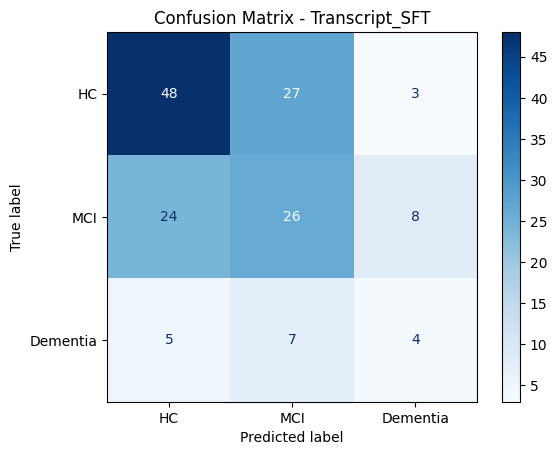

Classification report:
              precision    recall  f1-score   support

          HC       0.62      0.62      0.62        78
         MCI       0.43      0.45      0.44        58
    Dementia       0.27      0.25      0.26        16

    accuracy                           0.51       152
   macro avg       0.44      0.44      0.44       152
weighted avg       0.51      0.51      0.51       152

Mean accuracy over folds: 0.512
Mean macro F1 over folds: 0.407


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

CLASS_NAMES = ["HC", "MCI", "Dementia"]

# Build confusion matrices and classification reports for the best configs for each transcript type
# NOTE: This fully retrains the model with new random initialization, resulting in different F1 scores than during grid search
for transcript_col in TRANSCRIPT_COLS:
    print(f"\nConfusion matrix for {transcript_col}:")

    df = df_by_transcript[transcript_col]
    max_len = MAX_LEN_BY_TRANSCRIPT[transcript_col]
    config = best_configs[transcript_col]

    y_true, y_pred, fold_metrics = run_cv_collect_predictions(
        transcript_col=transcript_col,
        df=df,
        config=config,
        max_len=max_len,
        n_splits=5,
        seed=42,
        batch_size=16,
        max_epochs=30,
    )

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Confusion Matrix - {transcript_col}")
    # Save confusion matrix
    filename = f"confusion_matrix_{transcript_col}.png"
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    
    plt.show()

    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    accs = [m["accuracy"] for m in fold_metrics]
    macros = [m["macro_f1"] for m in fold_metrics]
    print(f"Mean accuracy over folds: {np.mean(accs):.3f}")
    print(f"Mean macro F1 over folds: {np.mean(macros):.3f}")


In [ ]:
# Metrics  for exploratory comparison
metrics_to_avg = [
    "mean_accuracy",
    "mean_macro_f1",
    "mean_weighted_f1",
    "mean_precision_macro",
    "mean_recall_macro",
    "mean_precision_weighted",
    "mean_recall_weighted",
]

# Average these metrics across all configs per transcript type
transcript_summary = (
    results_df
    .groupby("transcript_col")[metrics_to_avg]
    .mean()
    .reset_index()
)

# Sort by macro F1 (strongest signal of "overall balanced performance")
transcript_summary_sorted = transcript_summary.sort_values(
    "mean_macro_f1", ascending=False
)

display(transcript_summary_sorted)


,transcript_col,mean_accuracy,mean_macro_f1,mean_weighted_f1,mean_precision_macro,mean_recall_macro,mean_precision_weighted,mean_recall_weighted
2,Transcript_SFT,0.483076,0.346895,0.438193,0.375960,0.389875,0.468800,0.483076
0,Transcript_CTD,0.504602,0.341691,0.451563,0.370087,0.382349,0.477966,0.504602
1,Transcript_PFT,0.440324,0.294611,0.379750,0.311805,0.348255,0.400629,0.440324
